# Notebook Defense Sampling Strategy Comparison

This notebook loads every `notebook_defense_results.csv` under `results/notebook_defense`, parses the experiment folder names, and compares the defense results across sampling strategies, feature selectors, and value selectors.

The main comparisons use these metrics:

- `poison_recall`: higher means the defense removed more poisoned samples.
- `clean_false_positive_rate`: lower means fewer clean training rows were removed.
- `clean_accuracy`: higher is better after filtering and retraining.
- `watermarked_malware_detection_rate`: higher means the retrained model detects more watermarked malware.
- `watermarked_malware_evasion_rate`: lower means the watermark attack evades less often.


In [1]:
from pathlib import Path
import os
import tempfile

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'matplotlib-cache'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import FileLink, display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 120)


def find_results_dir():
    env_path = os.environ.get('DEFENSE_RESULTS_DIR')
    if env_path:
        candidate = Path(env_path).expanduser().resolve()
        if candidate.exists():
            return candidate
        raise FileNotFoundError(f'DEFENSE_RESULTS_DIR does not exist: {candidate}')

    start = Path.cwd().resolve()
    candidates = []
    for base in (start, *start.parents):
        candidates.extend([
            base / 'results' / 'notebook_defense',
            base / '..' / 'results' / 'notebook_defense',
            base if base.name == 'notebook_defense' else None,
        ])

    for candidate in candidates:
        if candidate is None:
            continue
        candidate = candidate.resolve()
        if list(candidate.glob('*/*/notebook_defense_results.csv')):
            return candidate

    raise FileNotFoundError(
        'Could not find results/notebook_defense. Run this notebook from the project root or set DEFENSE_RESULTS_DIR.'
    )


RESULTS_DIR = find_results_dir()
print(f'Using results directory: {RESULTS_DIR}')

Using results directory: /Users/falcon/Machine Learning/Severi Data Poisoning Attack/results/notebook_defense


In [2]:
METRICS_HIGHER_IS_BETTER = [
    'poison_recall',
    'clean_accuracy',
    'watermarked_malware_detection_rate',
]
METRICS_LOWER_IS_BETTER = [
    'clean_false_positive_rate',
    'watermarked_malware_evasion_rate',
]
KEY_METRICS = METRICS_HIGHER_IS_BETTER + METRICS_LOWER_IS_BETTER


def parse_experiment_name(name):
    tokens = name.split('__')
    if len(tokens) != 5:
        raise ValueError(f'Unexpected experiment directory name: {name}')
    dataset, model_id, feature_selector, value_selector, target_features = tokens
    return {
        'dataset': dataset,
        'model_id': model_id,
        'feature_selector': feature_selector,
        'value_selector': value_selector,
        'target_features': target_features,
        'selector_pair': f'{feature_selector} + {value_selector}',
    }


def load_one_csv(csv_path):
    rel = csv_path.relative_to(RESULTS_DIR)
    sampling_strategy = rel.parts[0]
    experiment_name = rel.parts[1]
    metadata = parse_experiment_name(experiment_name)

    df = pd.read_csv(csv_path)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')].copy()
    df.insert(0, 'sampling_strategy', sampling_strategy)
    df.insert(1, 'experiment_name', experiment_name)
    for column, value in metadata.items():
        df[column] = value
    df['csv_path'] = str(csv_path)
    return df


csv_files = sorted(RESULTS_DIR.glob('*/*/notebook_defense_results.csv'))
if not csv_files:
    raise FileNotFoundError(f'No notebook_defense_results.csv files found under {RESULTS_DIR}')

results_df = pd.concat([load_one_csv(path) for path in csv_files], ignore_index=True)

for column in ['removed_total', 'removed_poison', 'removed_clean', 'poison_total', 'filtered_train_rows', *KEY_METRICS, 'clean_fp_rate', 'clean_fn_rate']:
    if column in results_df.columns:
        results_df[column] = pd.to_numeric(results_df[column], errors='coerce')

removal_denominator = results_df['removed_total'].where(results_df['removed_total'].ne(0), np.nan)
results_df['poison_removal_precision'] = (results_df['removed_poison'] / removal_denominator).astype('float64')

baseline = (
    results_df[results_df['defense'].eq('backdoored_before_defense')]
    [['sampling_strategy', 'selector_pair', 'watermarked_malware_detection_rate', 'watermarked_malware_evasion_rate']]
    .rename(columns={
        'watermarked_malware_detection_rate': 'baseline_watermarked_detection_rate',
        'watermarked_malware_evasion_rate': 'baseline_watermarked_evasion_rate',
    })
)
results_df = results_df.merge(baseline, on=['sampling_strategy', 'selector_pair'], how='left')
results_df['detection_rate_delta_vs_baseline'] = (
    results_df['watermarked_malware_detection_rate'] - results_df['baseline_watermarked_detection_rate']
)
results_df['evasion_rate_delta_vs_baseline'] = (
    results_df['watermarked_malware_evasion_rate'] - results_df['baseline_watermarked_evasion_rate']
)

metadata_columns = [
    'sampling_strategy', 'defense', 'dataset', 'model_id', 'feature_selector',
    'value_selector', 'selector_pair', 'target_features'
]

print(f'Loaded {len(csv_files)} CSV files and {len(results_df)} result rows.')
display(results_df[metadata_columns + KEY_METRICS + ['detection_rate_delta_vs_baseline', 'evasion_rate_delta_vs_baseline']])

Loaded 24 CSV files and 72 result rows.


,sampling_strategy,defense,dataset,model_id,feature_selector,value_selector,selector_pair,target_features,poison_recall,clean_accuracy,watermarked_malware_detection_rate,clean_false_positive_rate,watermarked_malware_evasion_rate,detection_rate_delta_vs_baseline,evasion_rate_delta_vs_baseline
0,cosine similarity,backdoored_before_defense,ember,lightgbm,combined_shap,combined_shap,combined_shap + combined_shap,feasible,NaN,0.873265,0.122060,NaN,0.877940,0.000000,0.000000
1,cosine similarity,isolation_forest,ember,lightgbm,combined_shap,combined_shap,combined_shap + combined_shap,feasible,0.001667,0.876815,0.163925,0.036342,0.836075,0.041865,-0.041865
2,cosine similarity,spectral_signature,ember,lightgbm,combined_shap,combined_shap,combined_shap + combined_shap,feasible,0.000000,0.893625,0.158242,0.007307,0.841758,0.036182,-0.036182
3,cosine similarity,backdoored_before_defense,ember,lightgbm,shap_largest_abs,argmin_Nv_sum_abs_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,feasible,NaN,0.885710,0.046900,NaN,0.953100,0.000000,0.000000
4,cosine similarity,isolation_forest,ember,lightgbm,shap_largest_abs,argmin_Nv_sum_abs_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,feasible,0.986667,0.895220,0.862249,0.025478,0.137751,0.815348,-0.815348
5,cosine similarity,spectral_signature,ember,lightgbm,shap_largest_abs,argmin_Nv_sum_abs_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,feasible,0.000000,0.891245,0.072847,0.007307,0.927153,0.025947,-0.025947
6,cosine similarity,backdoored_before_defense,ember,lightgbm,shap_largest_abs,min_population_new,shap_largest_abs + min_population_new,feasible,NaN,0.904100,0.003319,NaN,0.996681,0.000000,0.000000
7,cosine similarity,isolation_forest,ember,lightgbm,shap_largest_abs,min_population_new,shap_largest_abs + min_population_new,feasible,1.000000,0.881170,0.540113,0.024346,0.459887,0.536794,-0.536794
8,cosine similarity,spectral_signature,ember,lightgbm,shap_largest_abs,min_population_new,shap_largest_abs + min_population_new,feasible,0.083333,0.868840,0.003823,0.006698,0.996177,0.000504,-0.000504
9,distribution based,backdoored_before_defense,ember,lightgbm,combined_shap,combined_shap,combined_shap + combined_shap,feasible,NaN,0.903975,0.048205,NaN,0.951795,0.000000,0.000000


## Coverage

This table confirms which sampling strategies, selector pairs, and defense rows are present.

In [3]:
coverage = (
    results_df
    .groupby(['sampling_strategy', 'selector_pair'], as_index=False)
    .agg(
        csv_count=('csv_path', 'nunique'),
        defense_rows=('defense', 'nunique'),
        defenses=('defense', lambda values: ', '.join(sorted(values.unique()))),
    )
    .sort_values(['sampling_strategy', 'selector_pair'])
)
display(coverage)

,sampling_strategy,selector_pair,csv_count,defense_rows,defenses
0,cosine similarity,combined_shap + combined_shap,1,3,"backdoored_before_defense, isolation_forest, s..."
1,cosine similarity,shap_largest_abs + argmin_Nv_sum_abs_shap,1,3,"backdoored_before_defense, isolation_forest, s..."
2,cosine similarity,shap_largest_abs + min_population_new,1,3,"backdoored_before_defense, isolation_forest, s..."
3,distribution based,combined_shap + combined_shap,1,3,"backdoored_before_defense, isolation_forest, s..."
4,distribution based,shap_largest_abs + argmin_Nv_sum_abs_shap,1,3,"backdoored_before_defense, isolation_forest, s..."
5,distribution based,shap_largest_abs + min_population_new,1,3,"backdoored_before_defense, isolation_forest, s..."
6,feature based distance,combined_shap + combined_shap,1,3,"backdoored_before_defense, isolation_forest, s..."
7,feature based distance,shap_largest_abs + argmin_Nv_sum_abs_shap,1,3,"backdoored_before_defense, isolation_forest, s..."
8,feature based distance,shap_largest_abs + min_population_new,1,3,"backdoored_before_defense, isolation_forest, s..."
9,jaccard distance,combined_shap + combined_shap,1,3,"backdoored_before_defense, isolation_forest, s..."


## Main Summary Table

The baseline row `backdoored_before_defense` is useful context, but the strategy comparison below focuses on actual defense methods.

In [4]:
defense_df = results_df[~results_df['defense'].eq('backdoored_before_defense')].copy()

summary_columns = [
    'sampling_strategy', 'selector_pair', 'defense',
    'removed_total', 'removed_poison', 'removed_clean', 'poison_total',
    'poison_recall', 'poison_removal_precision', 'clean_false_positive_rate',
    'clean_accuracy', 'watermarked_malware_detection_rate', 'watermarked_malware_evasion_rate',
    'detection_rate_delta_vs_baseline', 'evasion_rate_delta_vs_baseline',
]

summary_df = (
    defense_df[summary_columns]
    .sort_values(['defense', 'selector_pair', 'sampling_strategy'])
    .reset_index(drop=True)
)

display(summary_df.style.format({
    'poison_recall': '{:.3f}',
    'poison_removal_precision': '{:.3f}',
    'clean_false_positive_rate': '{:.3f}',
    'clean_accuracy': '{:.3f}',
    'watermarked_malware_detection_rate': '{:.3f}',
    'watermarked_malware_evasion_rate': '{:.3f}',
    'detection_rate_delta_vs_baseline': '{:+.3f}',
    'evasion_rate_delta_vs_baseline': '{:+.3f}',
}))

main_summary_csv = Path('notebook_defense_comparison_outputs') / 'main_summary_table.csv'
main_summary_csv.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(main_summary_csv, index=False)

print(f'Saved main summary table CSV to: {main_summary_csv.resolve()}')
display(FileLink(str(main_summary_csv), result_html_prefix='Download main summary table CSV: '))

,sampling_strategy,selector_pair,defense,removed_total,removed_poison,removed_clean,poison_total,poison_recall,poison_removal_precision,clean_false_positive_rate,clean_accuracy,watermarked_malware_detection_rate,watermarked_malware_evasion_rate,detection_rate_delta_vs_baseline,evasion_rate_delta_vs_baseline
0,cosine similarity,combined_shap + combined_shap,isolation_forest,2985,1,2984,600.000000,0.002,0.000,0.036,0.877,0.164,0.836,+0.042,-0.042
1,distribution based,combined_shap + combined_shap,isolation_forest,2817,2,2815,600.000000,0.003,0.001,0.034,0.876,0.056,0.944,+0.007,-0.007
2,feature based distance,combined_shap + combined_shap,isolation_forest,2925,0,2925,600.000000,0.000,0.000,0.036,0.877,0.105,0.895,+0.042,-0.042
3,jaccard distance,combined_shap + combined_shap,isolation_forest,2749,2,2747,600.000000,0.003,0.001,0.033,0.890,0.115,0.885,-0.017,+0.017
4,mahalanobis,combined_shap + combined_shap,isolation_forest,2811,0,2811,600.000000,0.000,0.000,0.034,0.875,0.116,0.884,+0.008,-0.008
5,random,combined_shap + combined_shap,isolation_forest,2718,3,2715,600.000000,0.005,0.001,0.033,0.890,0.160,0.840,-0.008,+0.008
6,shap contribution,combined_shap + combined_shap,isolation_forest,2616,3,2613,600.000000,0.005,0.001,0.032,0.877,0.109,0.891,+0.028,-0.028
7,wasserstein,combined_shap + combined_shap,isolation_forest,3214,0,3214,600.000000,0.000,0.000,0.039,0.886,0.101,0.899,-0.006,+0.006
8,cosine similarity,shap_largest_abs + argmin_Nv_sum_abs_shap,isolation_forest,2684,592,2092,600.000000,0.987,0.221,0.025,0.895,0.862,0.138,+0.815,-0.815
9,distribution based,shap_largest_abs + argmin_Nv_sum_abs_shap,isolation_forest,2695,600,2095,600.000000,1.000,0.223,0.026,0.900,0.903,0.097,+0.892,-0.892


Saved main summary table CSV to: /Users/falcon/Machine Learning/Severi Data Poisoning Attack/backdoor_notebook/notebook_defense_comparison_outputs/main_summary_table.csv


/Users/falcon/Machine Learning/Severi Data Poisoning Attack/backdoor_notebook/notebook_defense_comparison_outputs/main_summary_table.csv

## Best Sampling Strategies Per Defense And Selector

The score is a compact rank helper. It averages normalized versions of the key metrics, treating `poison_recall`, `clean_accuracy`, and `watermarked_malware_detection_rate` as higher-is-better, and `clean_false_positive_rate` plus `watermarked_malware_evasion_rate` as lower-is-better.

In [5]:
def add_metric_score(df, group_columns):
    scored = df.copy()
    score_columns = []

    for metric in METRICS_HIGHER_IS_BETTER:
        column = f'{metric}_score'
        denom = scored.groupby(group_columns)[metric].transform(lambda s: s.max() - s.min())
        scored[column] = (scored[metric] - scored.groupby(group_columns)[metric].transform('min')) / denom.where(denom.ne(0), np.nan)
        scored[column] = scored[column].fillna(1.0)
        score_columns.append(column)

    for metric in METRICS_LOWER_IS_BETTER:
        column = f'{metric}_score'
        denom = scored.groupby(group_columns)[metric].transform(lambda s: s.max() - s.min())
        scored[column] = (scored.groupby(group_columns)[metric].transform('max') - scored[metric]) / denom.where(denom.ne(0), np.nan)
        scored[column] = scored[column].fillna(1.0)
        score_columns.append(column)

    scored['overall_score'] = scored[score_columns].mean(axis=1)
    return scored


ranked_df = add_metric_score(summary_df, ['defense', 'selector_pair'])
ranked_df['rank_within_defense_selector'] = (
    ranked_df.groupby(['defense', 'selector_pair'])['overall_score']
    .rank(method='dense', ascending=False)
    .astype(int)
)

top_ranked = ranked_df.sort_values(['defense', 'selector_pair', 'rank_within_defense_selector', 'sampling_strategy'])

display(top_ranked[[
    'defense', 'selector_pair', 'rank_within_defense_selector', 'sampling_strategy', 'overall_score',
    'poison_recall', 'clean_false_positive_rate', 'clean_accuracy',
    'watermarked_malware_detection_rate', 'watermarked_malware_evasion_rate',
]].style.format({
    'overall_score': '{:.3f}',
    'poison_recall': '{:.3f}',
    'clean_false_positive_rate': '{:.3f}',
    'clean_accuracy': '{:.3f}',
    'watermarked_malware_detection_rate': '{:.3f}',
    'watermarked_malware_evasion_rate': '{:.3f}',
}))

,defense,selector_pair,rank_within_defense_selector,sampling_strategy,overall_score,poison_recall,clean_false_positive_rate,clean_accuracy,watermarked_malware_detection_rate,watermarked_malware_evasion_rate
5,isolation_forest,combined_shap + combined_shap,1,random,0.953,0.005,0.033,0.890,0.160,0.840
3,isolation_forest,combined_shap + combined_shap,2,jaccard distance,0.705,0.003,0.033,0.890,0.115,0.885
6,isolation_forest,combined_shap + combined_shap,3,shap contribution,0.623,0.005,0.032,0.877,0.109,0.891
0,isolation_forest,combined_shap + combined_shap,4,cosine similarity,0.562,0.002,0.036,0.877,0.164,0.836
4,isolation_forest,combined_shap + combined_shap,5,mahalanobis,0.357,0.000,0.034,0.875,0.116,0.884
7,isolation_forest,combined_shap + combined_shap,6,wasserstein,0.307,0.000,0.039,0.886,0.101,0.899
2,isolation_forest,combined_shap + combined_shap,7,feature based distance,0.306,0.000,0.036,0.877,0.105,0.895
1,isolation_forest,combined_shap + combined_shap,8,distribution based,0.272,0.003,0.034,0.876,0.056,0.944
11,isolation_forest,shap_largest_abs + argmin_Nv_sum_abs_shap,1,jaccard distance,0.960,1.000,0.024,0.903,0.828,0.172
9,isolation_forest,shap_largest_abs + argmin_Nv_sum_abs_shap,2,distribution based,0.931,1.000,0.026,0.900,0.903,0.097


## Pivot Tables

Each pivot compares sampling strategies for a single metric. Use these to inspect one defense method at a time.

In [6]:
def show_metric_pivots(metric):
    print()
    print(f'Metric: {metric}')
    for defense_name in sorted(summary_df['defense'].unique()):
        pivot = (
            summary_df[summary_df['defense'].eq(defense_name)]
            .pivot_table(index='sampling_strategy', columns='selector_pair', values=metric, aggfunc='mean')
            .sort_index()
        )
        print()
        print(f'Defense: {defense_name}')
        display(pivot.style.format('{:.3f}'))


for metric in KEY_METRICS + ['detection_rate_delta_vs_baseline', 'evasion_rate_delta_vs_baseline']:
    show_metric_pivots(metric)


Metric: poison_recall

Defense: isolation_forest


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
sampling_strategy,,,
cosine similarity,0.002,0.987,1.000
distribution based,0.003,1.000,1.000
feature based distance,0.000,1.000,1.000
jaccard distance,0.003,1.000,1.000
mahalanobis,0.000,0.120,1.000
random,0.005,0.995,1.000
shap contribution,0.005,1.000,1.000
wasserstein,0.000,0.667,1.000



Defense: spectral_signature


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
sampling_strategy,,,
cosine similarity,0.000,0.000,0.083
distribution based,0.007,0.003,0.203
feature based distance,0.067,0.000,0.173
jaccard distance,0.015,0.002,0.040
mahalanobis,0.005,0.000,0.253
random,0.007,0.003,0.012
shap contribution,0.025,0.005,0.220
wasserstein,0.057,0.000,0.128



Metric: clean_accuracy

Defense: isolation_forest


...

selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
sampling_strategy,,,
cosine similarity,0.036,0.026,0.001
distribution based,-0.001,-0.001,0.000
feature based distance,0.054,0.009,0.002
jaccard distance,0.002,-0.019,0.001
mahalanobis,-0.003,0.014,0.006
random,0.003,-0.025,-0.000
shap contribution,0.011,-0.014,-0.001
wasserstein,-0.010,-0.007,0.002



Metric: evasion_rate_delta_vs_baseline

Defense: isolation_forest


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
sampling_strategy,,,
cosine similarity,-0.042,-0.815,-0.537
distribution based,-0.007,-0.892,-0.727
feature based distance,-0.042,-0.859,-0.823
jaccard distance,0.017,-0.744,-0.456
mahalanobis,-0.008,-0.048,-0.706
random,0.008,-0.789,-0.514
shap contribution,-0.028,-0.861,-0.740
wasserstein,0.006,-0.139,-0.507



Defense: spectral_signature


selector_pair,combined_shap + combined_shap,shap_largest_abs + argmin_Nv_sum_abs_shap,shap_largest_abs + min_population_new
sampling_strategy,,,
cosine similarity,-0.036,-0.026,-0.001
distribution based,0.001,0.001,-0.000
feature based distance,-0.054,-0.009,-0.002
jaccard distance,-0.002,0.019,-0.001
mahalanobis,0.003,-0.014,-0.006
random,-0.003,0.025,0.000
shap contribution,-0.011,0.014,0.001
wasserstein,0.010,0.007,-0.002


## Heatmaps

These heatmaps make it easier to scan which sampling strategies perform best for each selector pair. The color scale is per defense and metric.

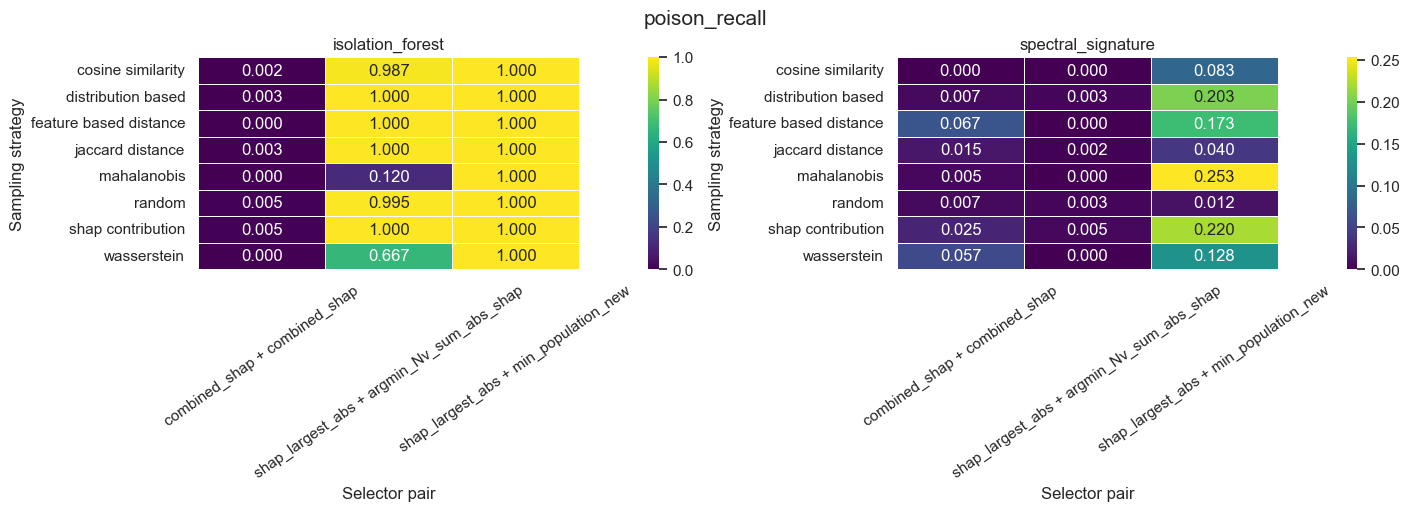

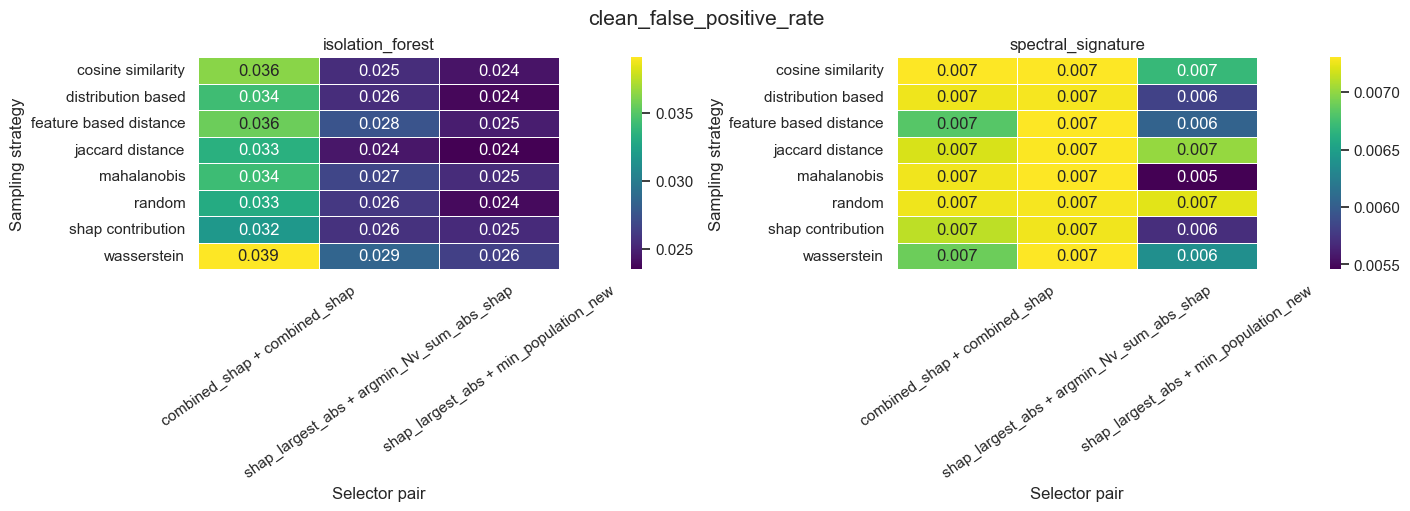

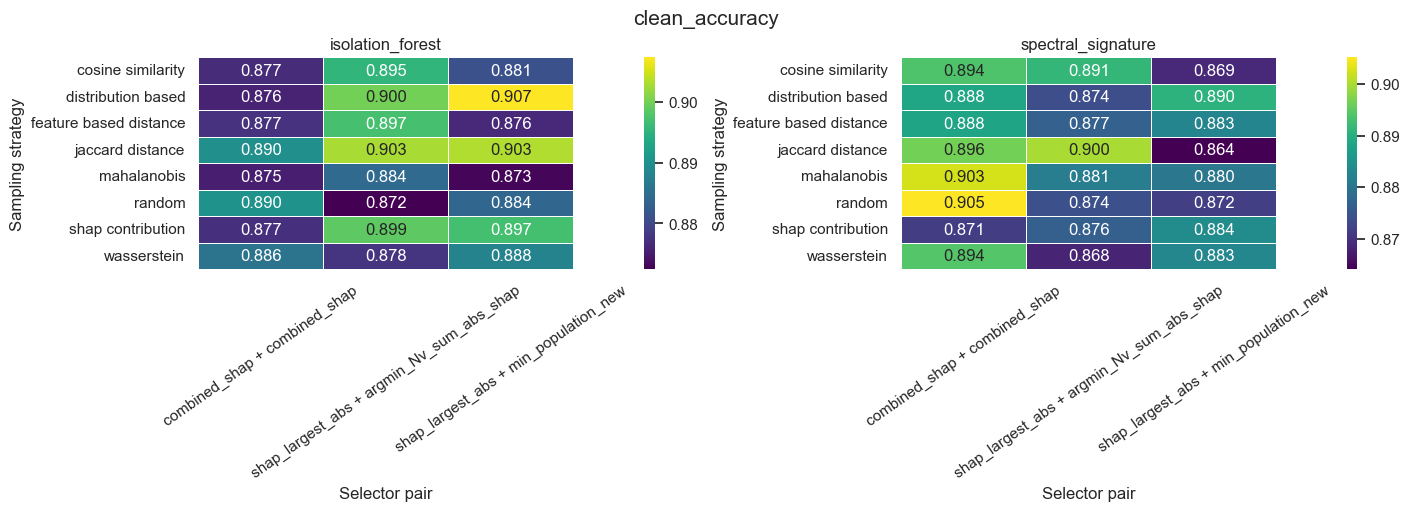

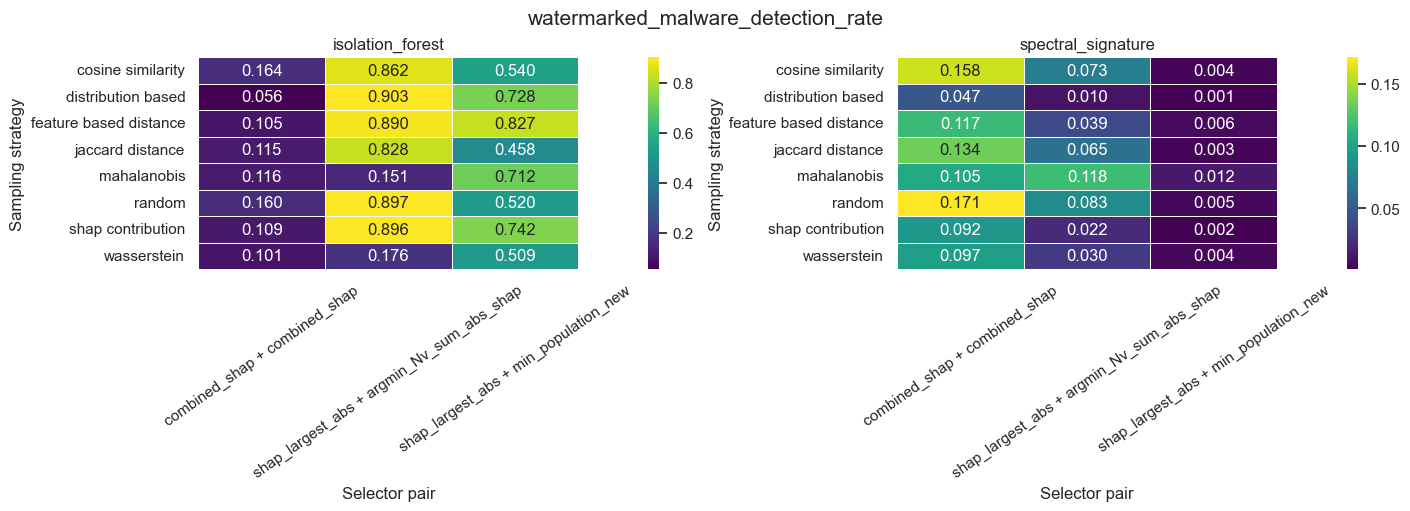

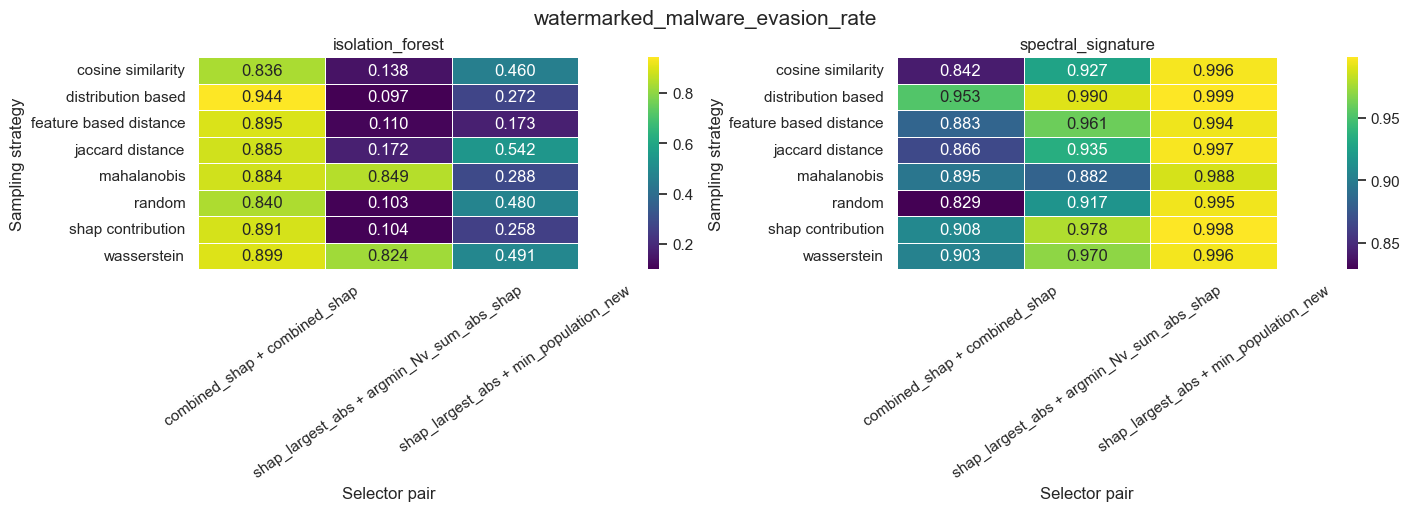

In [7]:
def plot_metric_heatmaps(metric):
    defenses = sorted(summary_df['defense'].unique())
    fig, axes = plt.subplots(1, len(defenses), figsize=(7 * len(defenses), 5), constrained_layout=True)
    if len(defenses) == 1:
        axes = [axes]

    for ax, defense_name in zip(axes, defenses):
        pivot = (
            summary_df[summary_df['defense'].eq(defense_name)]
            .pivot_table(index='sampling_strategy', columns='selector_pair', values=metric, aggfunc='mean')
            .sort_index()
        )
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', linewidths=0.5, ax=ax)
        ax.set_title(defense_name)
        ax.set_xlabel('Selector pair')
        ax.set_ylabel('Sampling strategy')
        ax.tick_params(axis='x', rotation=35)

    fig.suptitle(metric, fontsize=15)
    plt.show()


for metric in ['poison_recall', 'clean_false_positive_rate', 'clean_accuracy', 'watermarked_malware_detection_rate', 'watermarked_malware_evasion_rate']:
    plot_metric_heatmaps(metric)

## Bar Charts By Defense

These plots show the same comparison as grouped bars. They are useful when you want to compare one metric across all sampling strategies.

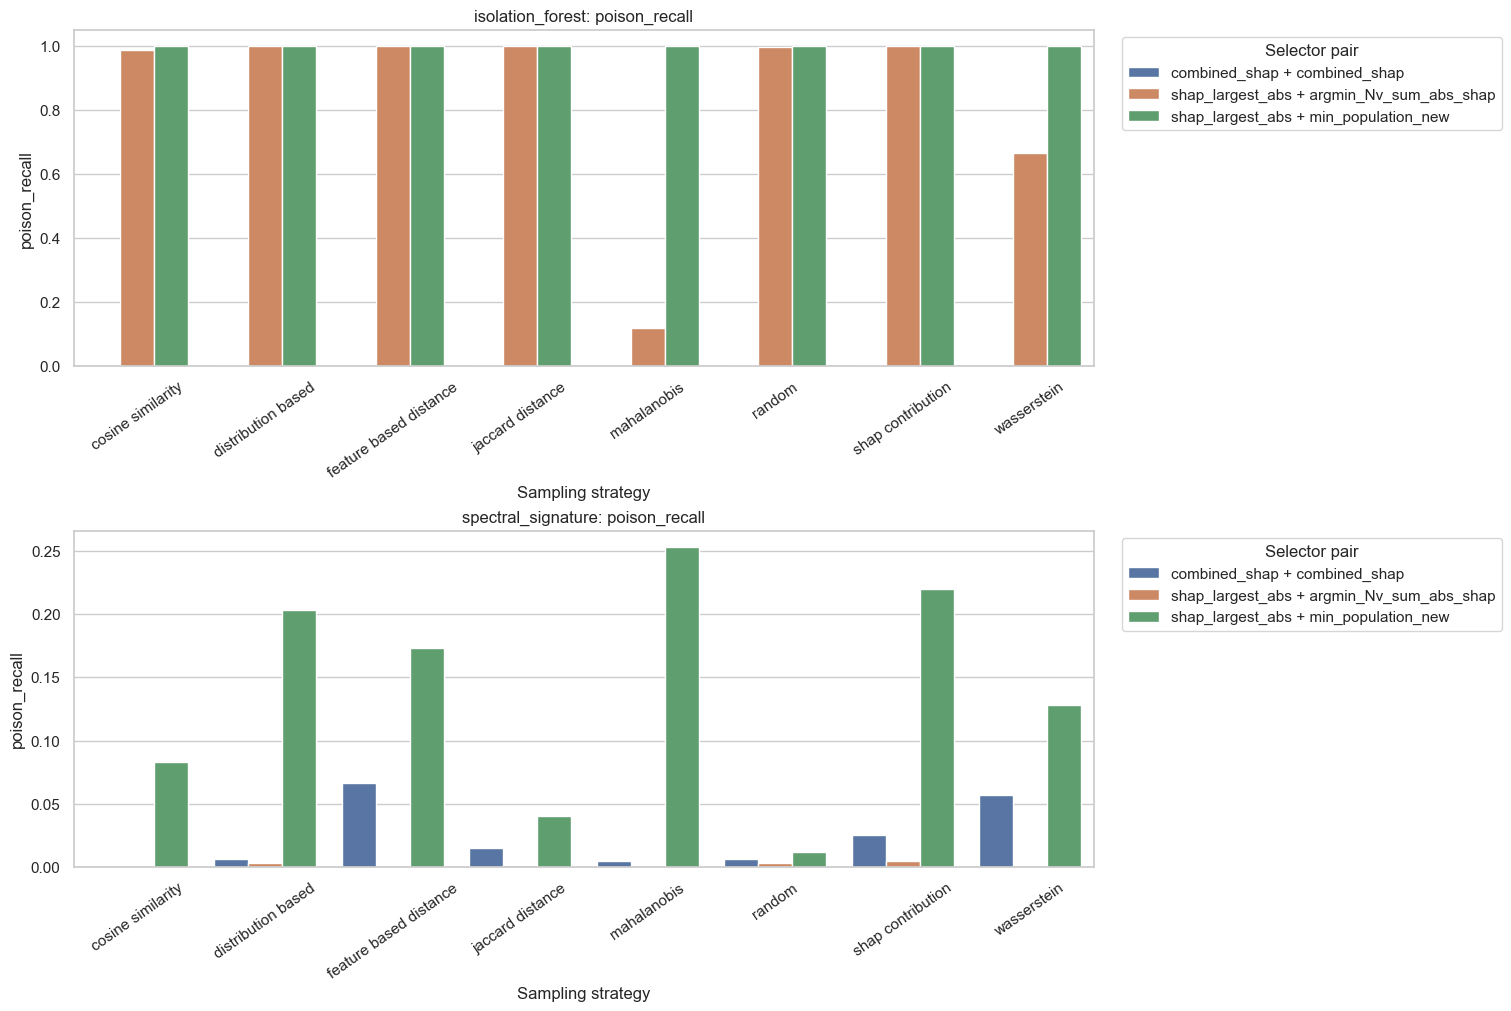

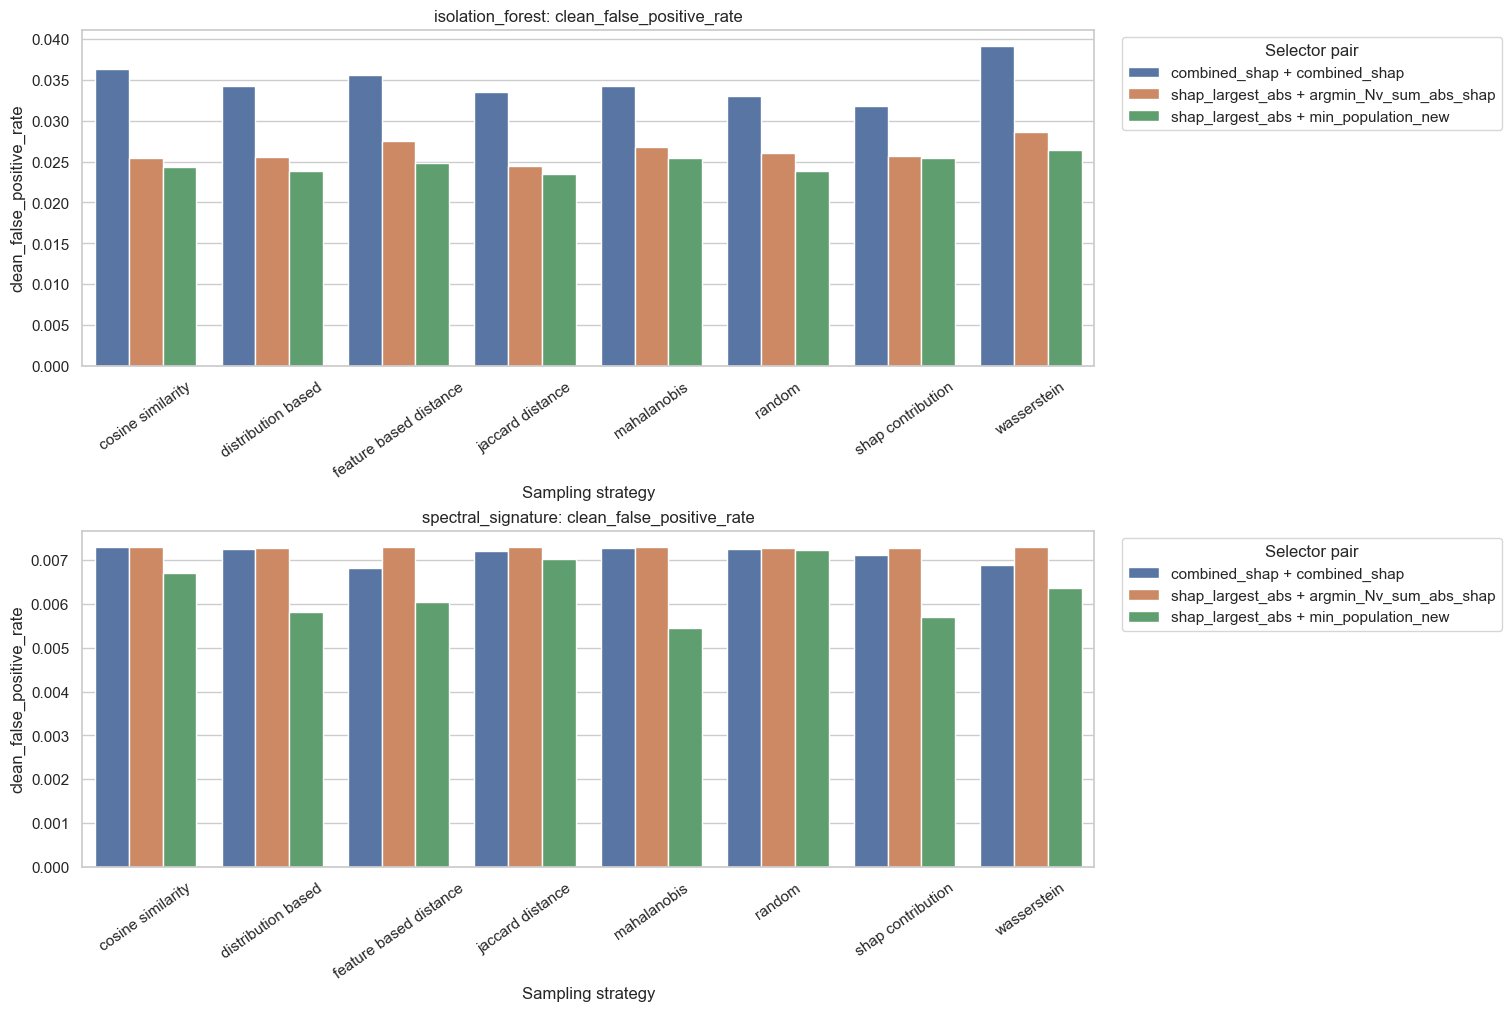

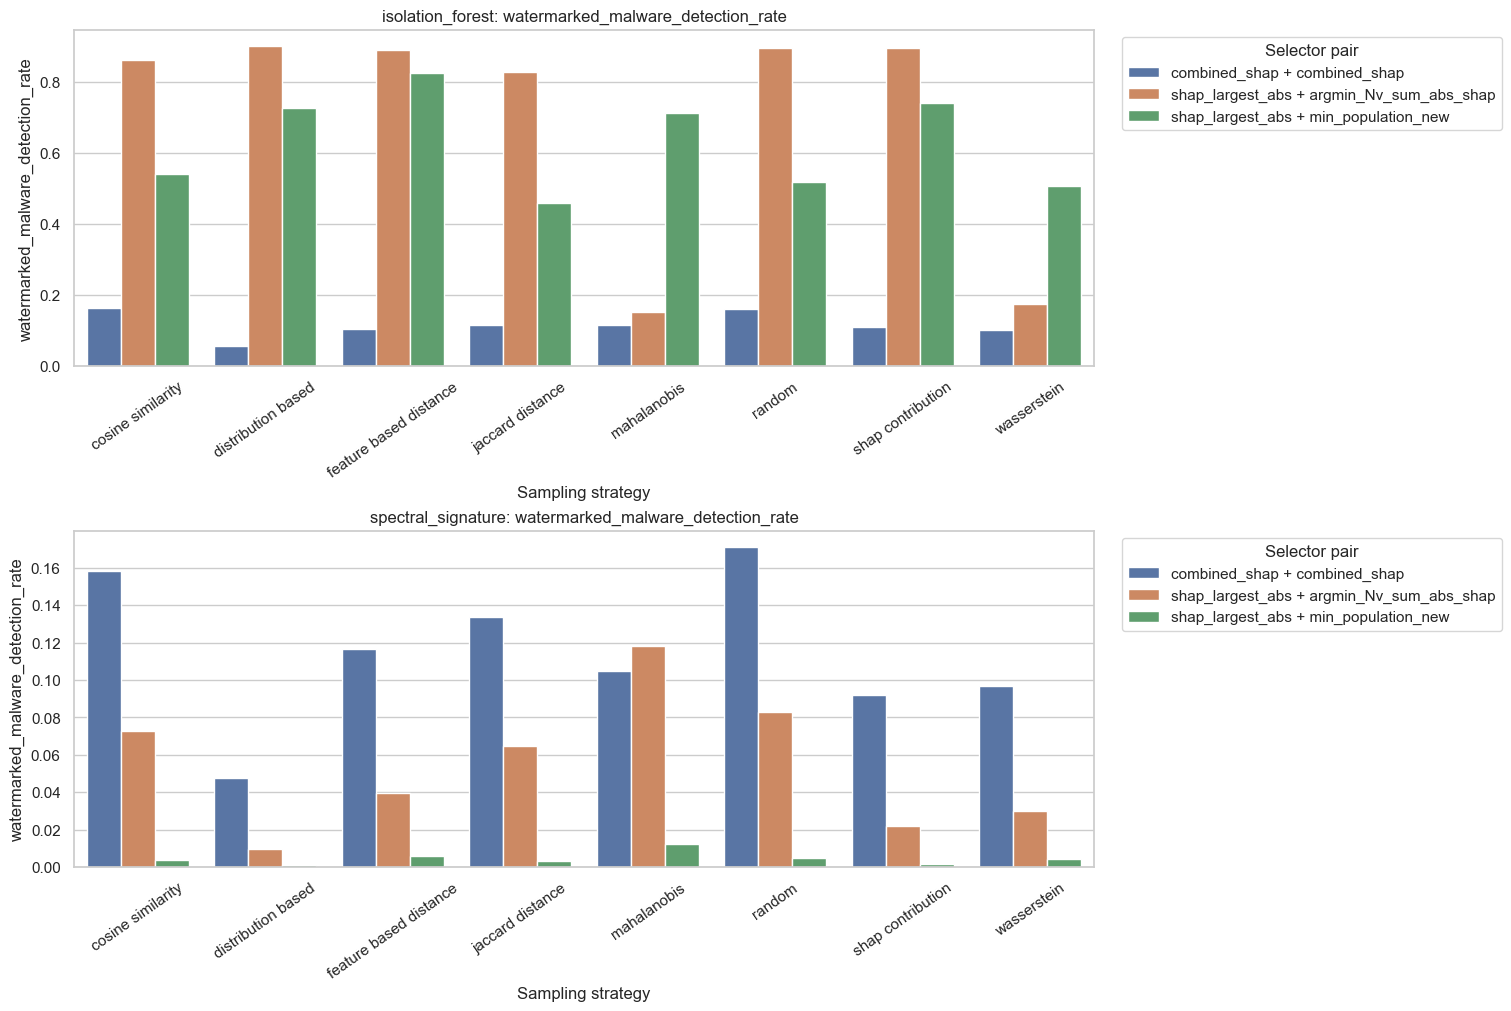

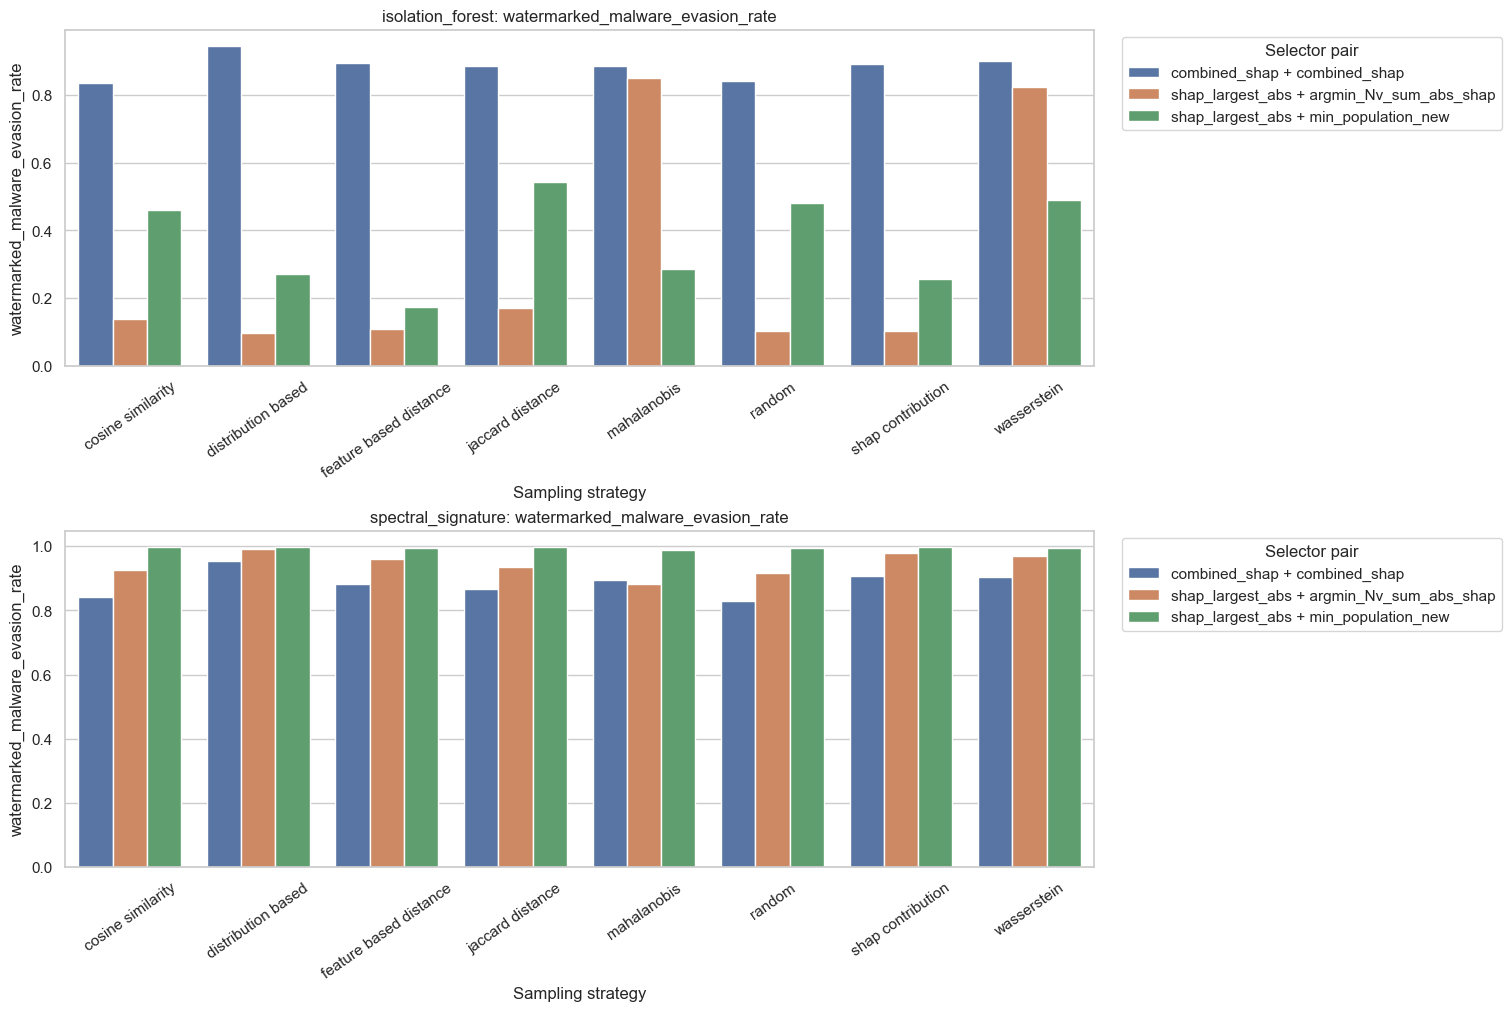

In [8]:
def plot_metric_bars(metric):
    defenses = sorted(summary_df['defense'].unique())
    fig, axes = plt.subplots(len(defenses), 1, figsize=(15, 5 * len(defenses)), constrained_layout=True)
    if len(defenses) == 1:
        axes = [axes]

    for ax, defense_name in zip(axes, defenses):
        plot_df = summary_df[summary_df['defense'].eq(defense_name)].sort_values(['sampling_strategy', 'selector_pair'])
        sns.barplot(
            data=plot_df,
            x='sampling_strategy',
            y=metric,
            hue='selector_pair',
            ax=ax,
        )
        ax.set_title(f'{defense_name}: {metric}')
        ax.set_xlabel('Sampling strategy')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=35)
        ax.legend(title='Selector pair', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.show()


for metric in ['poison_recall', 'clean_false_positive_rate', 'watermarked_malware_detection_rate', 'watermarked_malware_evasion_rate']:
    plot_metric_bars(metric)

## One-Number Strategy Ranking

This aggregates across defense methods and selector pairs. It is useful for a quick overview, but inspect the metric-specific plots before drawing conclusions.

,sampling_strategy,mean_overall_score,mean_rank,mean_poison_recall,mean_clean_false_positive_rate,mean_clean_accuracy,mean_watermarked_detection_rate,mean_watermarked_evasion_rate
5,random,0.598,3.83,0.337,0.017,0.883,0.306,0.694
6,shap contribution,0.593,3.83,0.376,0.017,0.884,0.310,0.690
3,jaccard distance,0.569,3.50,0.343,0.017,0.893,0.267,0.733
2,feature based distance,0.550,4.00,0.373,0.018,0.883,0.331,0.669
0,cosine similarity,0.506,5.17,0.345,0.018,0.884,0.300,0.700
1,distribution based,0.506,4.67,0.369,0.017,0.889,0.291,0.709
4,mahalanobis,0.480,4.83,0.230,0.018,0.883,0.202,0.798
7,wasserstein,0.330,6.17,0.309,0.019,0.883,0.153,0.847


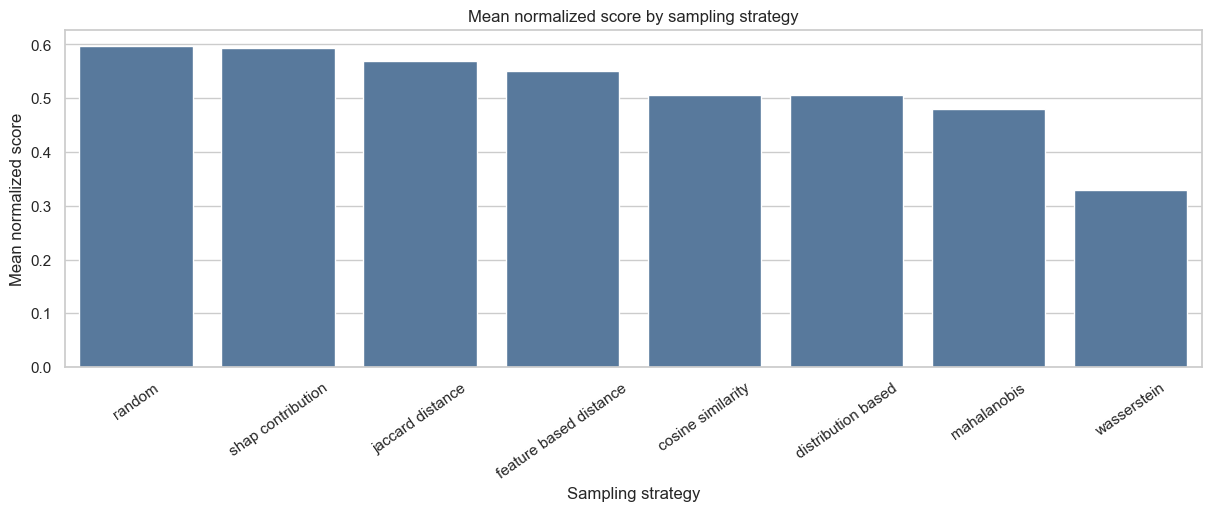

In [9]:
strategy_overview = (
    ranked_df
    .groupby('sampling_strategy', as_index=False)
    .agg(
        mean_overall_score=('overall_score', 'mean'),
        mean_rank=('rank_within_defense_selector', 'mean'),
        mean_poison_recall=('poison_recall', 'mean'),
        mean_clean_false_positive_rate=('clean_false_positive_rate', 'mean'),
        mean_clean_accuracy=('clean_accuracy', 'mean'),
        mean_watermarked_detection_rate=('watermarked_malware_detection_rate', 'mean'),
        mean_watermarked_evasion_rate=('watermarked_malware_evasion_rate', 'mean'),
    )
    .sort_values(['mean_overall_score', 'mean_poison_recall'], ascending=[False, False])
)

display(strategy_overview.style.format({
    'mean_overall_score': '{:.3f}',
    'mean_rank': '{:.2f}',
    'mean_poison_recall': '{:.3f}',
    'mean_clean_false_positive_rate': '{:.3f}',
    'mean_clean_accuracy': '{:.3f}',
    'mean_watermarked_detection_rate': '{:.3f}',
    'mean_watermarked_evasion_rate': '{:.3f}',
}))

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
sns.barplot(data=strategy_overview, x='sampling_strategy', y='mean_overall_score', ax=ax, color='#4c78a8')
ax.set_title('Mean normalized score by sampling strategy')
ax.set_xlabel('Sampling strategy')
ax.set_ylabel('Mean normalized score')
ax.tick_params(axis='x', rotation=35)
plt.show()

## Optional Export

Set `SAVE_TABLES = True` to save the combined long table, summary table, ranked table, and strategy overview as CSV files under `_comparison_outputs`.

In [10]:
SAVE_TABLES = False

if SAVE_TABLES:
    output_dir = RESULTS_DIR / '_comparison_outputs'
    output_dir.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(output_dir / 'combined_notebook_defense_results.csv', index=False)
    summary_df.to_csv(output_dir / 'defense_sampling_summary.csv', index=False)
    ranked_df.to_csv(output_dir / 'defense_sampling_ranked.csv', index=False)
    strategy_overview.to_csv(output_dir / 'strategy_overview.csv', index=False)
    print(f'Saved comparison tables to {output_dir}')
else:
    print('SAVE_TABLES is False, so no CSV files were written.')

SAVE_TABLES is False, so no CSV files were written.
